# Performance Evaluation Results


In [6]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from plot_utils import colors, set_plot_style, set_legend_style

RESULTS_DIR = 'results/performance'
EXTINCTIONS = 80, 200, 1000

In [7]:
set_plot_style()

In [8]:
volumes = set()

results = {}
for subdir in os.listdir(RESULTS_DIR):
    subdir_path = os.path.join(RESULTS_DIR, subdir)
    if not os.path.isdir(subdir_path):
        continue
    results[subdir] = {}
    for filename in os.listdir(subdir_path):
        if not filename.endswith('.csv'):
            continue
        volume, extinction, *_ = filename[:-4].rsplit('_', 2)
        volumes.add(volume)
        with open(os.path.join(subdir_path, filename), 'r') as f:
            data = pd.read_csv(f)
            results[subdir][(volume, int(extinction))] = data

volumes = sorted(volumes)

In [9]:
results['path_tracing']['chameleon', 200]

,time,frame_index,fps,frame_time,stage_sample_gen,stage_direct,stage_indirect,stage_filter,stage_accumulate,stage_compose
0,1.0,48,12.0,83.5,12.440,1.980,6.547,-1,0.094,0.031
1,2.0,101,14.7,67.9,12.879,1.011,3.422,-1,0.093,0.030
2,3.0,157,14.2,70.4,12.217,1.303,4.270,-1,0.098,0.031
3,4.0,205,12.1,82.4,12.047,1.965,6.867,-1,0.094,0.030
4,5.0,254,12.9,77.5,9.014,2.465,7.958,-1,0.094,0.030
...,...,...,...,...,...,...,...,...,...,...
114,115.0,5576,14.8,67.5,12.723,1.102,3.443,-1,0.093,0.030
115,116.0,5633,14.7,68.1,12.108,1.140,3.939,-1,0.094,0.030
116,117.0,5682,12.4,80.9,11.977,1.953,6.212,-1,0.120,0.055
117,118.0,5732,13.0,76.7,9.051,2.399,7.826,-1,0.093,0.030


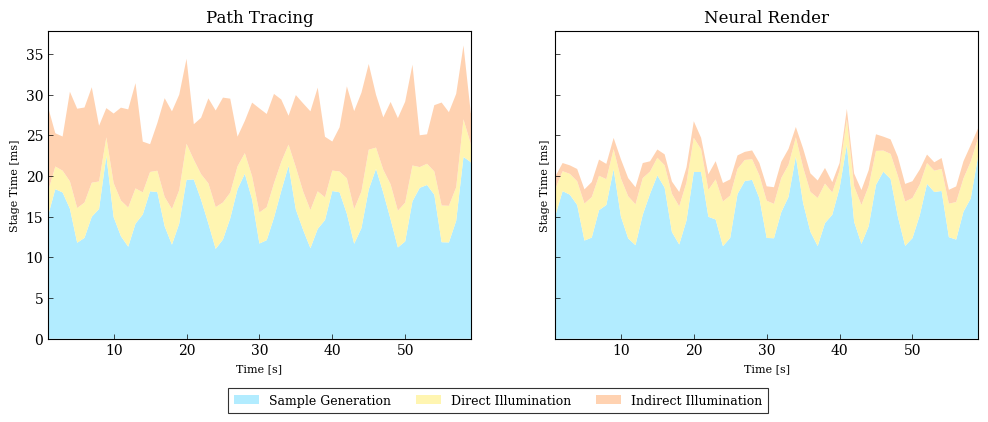

In [10]:
example = 'chameleon', 1000
stage_cols = ['stage_sample_gen', 'stage_direct', 'stage_indirect']

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for i, subdir in enumerate(['path_tracing', 'neural_render']):
    df = results[subdir][example]
    x = df['time']

    ax[i].stackplot(
        x,
        *[df[c] for c in stage_cols],
        labels=stage_cols,
        colors=[colors[5], colors[0], colors[2]],
    )

    ax[i].set_title(subdir.replace('_', ' ').title())
    ax[i].set_xlim(1, 59)
    ax[i].set_xlabel('Time [s]')
    ax[i].set_ylabel('Stage Time [ms]')

handles, labels = ax[0].get_legend_handles_labels()
labels = ['Sample Generation', 'Direct Illumination', 'Indirect Illumination']
legend = fig.legend(
    handles, labels, ncol=4, bbox_to_anchor=(0.5, 0), loc='upper center'
)
frame = legend.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(0.8)
frame.set_boxstyle('Square', pad=0.05)

plt.savefig(
    os.path.join(RESULTS_DIR, '..', 'plots', 'stage_times.pdf'), bbox_inches='tight'
)
plt.show()

In [11]:
sum_ours_Ld = 0
sum_ours_Li = 0
sum_pt_Ld = 0
sum_pt_Li = 0
speedups_Li = {}
speedups_L = {}

print(
    f'{"Dataset":<20} '
    f'{"Ext.":<5}   '
    f'{"Ours Ld":<16} '
    f'{"Ours Li":<16} '
    f'{"Ours L":<8}   '
    f'{"PT Ld":<16} '
    f'{"PT Li":<16} '
    f'{"PT L":<8}   '
    f'{"S Li":<5} '
    f'{"S L":<5}'
)

for volume in volumes:
    for i, extinction in enumerate(EXTINCTIONS):
        ours = results['neural_render'][volume, extinction]
        pt = results['path_tracing'][volume, extinction]

        ours_Ld = ours['stage_direct'].mean()
        ours_Ld_se = ours['stage_direct'].std() / np.sqrt(len(ours))
        ours_Li = ours['stage_indirect'].mean()
        ours_Li_se = ours['stage_indirect'].std() / np.sqrt(len(ours))
        pt_Ld = pt['stage_direct'].mean()
        pt_Ld_se = pt['stage_direct'].std() / np.sqrt(len(pt))
        pt_Li = pt['stage_indirect'].mean()
        pt_Li_se = pt['stage_indirect'].std() / np.sqrt(len(pt))

        ours_L = ours_Ld + ours_Li
        ours_L_se = np.sqrt(ours_Ld_se**2 + ours_Li_se**2)
        pt_L = pt_Ld + pt_Li
        pt_L_se = np.sqrt(pt_Ld_se**2 + pt_Li_se**2)
        speedup_Li = pt_Li / ours_Li
        speedup_L = pt_L / ours_L
        sum_ours_Ld += ours_Ld
        sum_ours_Li += ours_Li
        sum_pt_Ld += pt_Ld
        sum_pt_Li += pt_Li

        speedups_Li[(volume, extinction)] = speedup_Li
        speedups_L[volume, extinction] = speedup_L

        print(
            f'{volume if i == 0 else "":<20} '
            f'{extinction:<5}   '
            f'{f"{ours_Ld:.2f} ± {ours_Ld_se:.2f}":<16} '
            f'{f"{ours_Li:.2f} ± {ours_Li_se:.2f}":<16} '
            f'{ours_L:<8.2f}   '
            f'{f"{pt_Ld:.2f} ± {pt_Ld_se:.2f}":<16} '
            f'{f"{pt_Li:.2f} ± {pt_Li_se:.2f}":<16} '
            f'{pt_L:<8.2f}   '
            f'{speedup_Li:<5.2f} '
            f'{speedup_L:<5.2f}',
        )

sum_ours_L = sum_ours_Ld + sum_ours_Li
sum_pt_L = sum_pt_Ld + sum_pt_Li
overall_speedup_Li = sum_pt_Li / sum_ours_Li
overall_speedup_L = sum_pt_L / sum_ours_L

print(
    f'{"Overall":<20} '
    f'{"":<5}   '
    f'{sum_ours_Ld:<16.2f} '
    f'{sum_ours_Li:<16.2f} '
    f'{sum_ours_L:<8.2f}   '
    f'{sum_pt_Ld:<16.2f} '
    f'{sum_pt_Li:<16.2f} '
    f'{sum_pt_L:<8.2f}   '
    f'{overall_speedup_Li:<5.2f} '
    f'{overall_speedup_L:<5.2f}',
)

Dataset              Ext.    Ours Ld          Ours Li          Ours L     PT Ld            PT Li            PT L       S Li  S L  
bonsai               80      1.17 ± 0.01      1.31 ± 0.01      2.49       1.17 ± 0.01      1.34 ± 0.01      2.51       1.02  1.01 
                     200     2.87 ± 0.01      1.64 ± 0.01      4.51       2.80 ± 0.01      3.60 ± 0.01      6.41       2.19  1.42 
                     1000    5.19 ± 0.05      2.04 ± 0.01      7.22       4.99 ± 0.04      6.35 ± 0.05      11.34      3.11  1.57 
chameleon            80      1.38 ± 0.03      1.65 ± 0.03      3.03       1.35 ± 0.03      3.12 ± 0.06      4.47       1.89  1.48 
                     200     2.16 ± 0.05      1.73 ± 0.04      3.89       2.08 ± 0.05      6.92 ± 0.18      9.00       4.01  2.31 
                     1000    3.87 ± 0.10      1.74 ± 0.04      5.61       3.68 ± 0.08      9.13 ± 0.30      12.81      5.26  2.28 
csafe_heptane        80      0.64 ± 0.01      1.42 ± 0.02      2.06       0.65 ± 0.

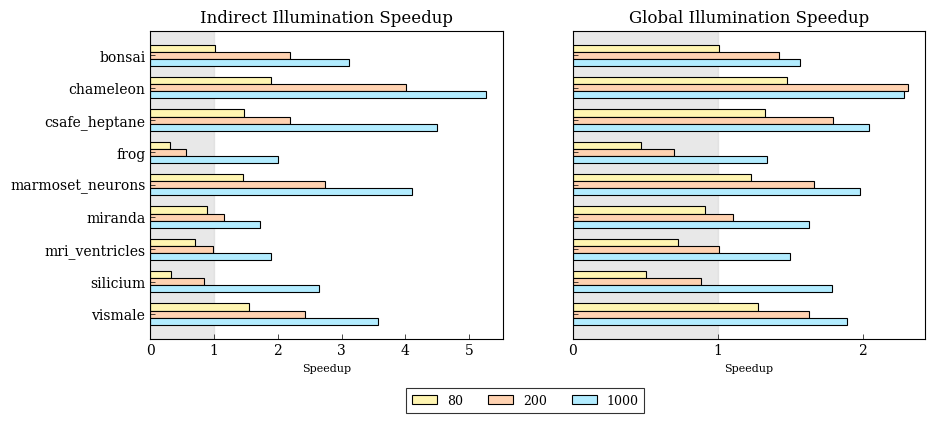

In [12]:
speedup_colors = {
    80: colors[0],
    200: colors[2],
    1000: colors[5],
}

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

ticks = []
ticks_labels = []

for i, volume in enumerate(reversed(volumes)):
    ticks.append(i)
    ticks_labels.append(volume)
    for j, extinction in enumerate(EXTINCTIONS):
        ax[0].barh(
            i - (j - 1) * 0.22,
            speedups_Li[volume, extinction],
            color=speedup_colors.get(extinction),
            height=0.22,
            label=str(extinction) if i == 0 else None,
            edgecolor='black',
            linewidth=0.8,
        )
        ax[1].barh(
            i - (j - 1) * 0.22,
            speedups_L[volume, extinction],
            color=speedup_colors.get(extinction),
            height=0.22,
            edgecolor='black',
            linewidth=0.8,
        )

ax[0].axvspan(0, 1, color='lightgray', alpha=0.5, zorder=0)
ax[1].axvspan(0, 1, color='lightgray', alpha=0.5, zorder=0)

ax[0].set_title('Indirect Illumination Speedup')
ax[1].set_title('Global Illumination Speedup')

ax[0].set_yticks(ticks)
ax[0].set_yticklabels(ticks_labels)
ax[1].set_yticks(ticks)
ax[0].set_xlabel('Speedup')
ax[1].set_xlabel('Speedup')

ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))

legend = fig.legend(
    loc='upper center',
    ncol=len(EXTINCTIONS),
    bbox_to_anchor=(0.5, 0),
)
set_legend_style(legend)

plt.savefig(
    os.path.join(RESULTS_DIR, '..', 'plots', 'speedups_L.pdf'), bbox_inches='tight'
)
plt.show()

In [13]:
sum_ours_ft = 0
sum_pt_ft = 0
speedups_ft = {}

print(
    f'{"Dataset":<20} '
    f'{"Ext.":<5}   '
    f'{"Ours Frame Time":<18} '
    f'{"Ours FPS":<18}   '
    f'{"PT Frame Time":<18} '
    f'{"PT FPS":<18}   '
    f'{"Speedup":<7}'
)

for volume in volumes:
    for i, extinction in enumerate(EXTINCTIONS):
        ours = results['neural_render'][volume, extinction]
        pt = results['path_tracing'][volume, extinction]

        ours_ft = ours['frame_time'].mean()
        ours_ft_se = ours['frame_time'].std() / np.sqrt(len(ours))
        ours_fps = ours['fps'].mean()
        ours_fps_se = ours['fps'].std() / np.sqrt(len(ours))
        pt_ft = pt['frame_time'].mean()
        pt_ft_se = pt['frame_time'].std() / np.sqrt(len(pt))
        pt_fps = pt['fps'].mean()
        pt_fps_se = pt['fps'].std() / np.sqrt(len(pt))

        speedup = pt_ft / ours_ft
        sum_ours_ft += ours_ft
        sum_pt_ft += pt_ft

        speedups_ft[(volume, extinction)] = speedup

        print(
            f'{volume if i == 0 else "":<20} '
            f'{extinction:<5}   '
            f'{f"{ours_ft:.2f} ± {ours_ft_se:.2f}":<18} '
            f'{f"{ours_fps:.2f} ± {ours_fps_se:.2f}":<18}   '
            f'{f"{pt_ft:.2f} ± {pt_ft_se:.2f}":<18} '
            f'{f"{pt_fps:.2f} ± {pt_fps_se:.2f}":<18}   '
            f'{speedup:<7.2f}',
        )

overall_speedup = sum_pt_ft / sum_ours_ft
print(
    f'{"Overall":<20} '
    f'{"":<5}   '
    f'{sum_ours_ft:<18.2f} '
    f'{"":<18}   '
    f'{sum_pt_ft:<18.2f} '
    f'{"":<18}   '
    f'{overall_speedup:<7.2f}',
)

Dataset              Ext.    Ours Frame Time    Ours FPS             PT Frame Time      PT FPS               Speedup
bonsai               80      20.62 ± 0.82       64.20 ± 3.46         21.13 ± 0.81       61.93 ± 3.34         1.02   
                     200     36.93 ± 0.25       27.22 ± 0.18         43.92 ± 0.21       22.83 ± 0.11         1.19   
                     1000    68.89 ± 0.30       14.54 ± 0.06         85.49 ± 0.42       11.73 ± 0.06         1.24   
chameleon            80      53.95 ± 0.35       18.63 ± 0.12         48.39 ± 0.36       20.81 ± 0.16         0.90   
                     200     61.10 ± 0.39       16.45 ± 0.11         80.15 ± 0.71       12.60 ± 0.11         1.31   
                     1000    85.10 ± 0.73       11.85 ± 0.10         111.94 ± 0.88      9.00 ± 0.07          1.32   
csafe_heptane        80      5.77 ± 0.02        173.63 ± 0.48        6.38 ± 0.03        157.14 ± 0.82        1.11   
                     200     6.91 ± 0.04        145.40 ± 0.93   

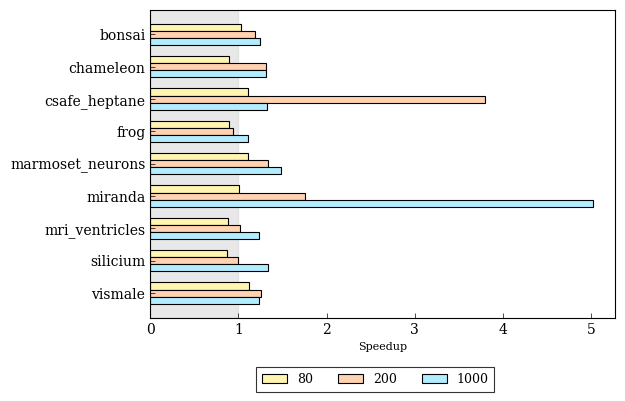

In [14]:
speedup_colors = {
    80: colors[0],
    200: colors[2],
    1000: colors[5],
}

fig, ax = plt.subplots(figsize=(6, 4))

ticks = []
ticks_labels = []

for i, volume in enumerate(reversed(volumes)):
    ticks.append(i)
    ticks_labels.append(volume)
    for j, extinction in enumerate(EXTINCTIONS):
        ax.barh(
            i - (j - 1) * 0.22,
            speedups_ft[volume, extinction],
            color=speedup_colors.get(extinction),
            height=0.22,
            label=str(extinction) if i == 0 else None,
            edgecolor='black',
            linewidth=0.8,
        )

ax.axvspan(0, 1, color='lightgray', alpha=0.5, zorder=0)

ax.set_yticks(ticks)
ax.set_yticklabels(ticks_labels)
ax.set_xlabel('Speedup')

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

legend = fig.legend(
    loc='upper center',
    ncol=len(EXTINCTIONS),
    bbox_to_anchor=(0.5, 0),
)
set_legend_style(legend)

plt.savefig(
    os.path.join(RESULTS_DIR, '..', 'plots', 'speedups_ft.pdf'), bbox_inches='tight'
)
plt.show()